# Demak boshladik 

In [199]:
import pandas as pd
import os 

In [200]:
df = pd.read_csv('gold_usd.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6399 non-null   str    
 1   Open    6397 non-null   float64
 2   High    6397 non-null   float64
 3   Low     6397 non-null   float64
 4   Close   6398 non-null   float64
 5   Volume  6396 non-null   float64
dtypes: float64(5), str(1)
memory usage: 300.1 KB


In [201]:
df.isna().sum()

Date      0
Open      2
High      2
Low       2
Close     1
Volume    3
dtype: int64

In [202]:
# Drop not much important columns
df.drop('Date', axis=1, inplace=True)

# Raw datasetni data/raw ichiga joylab oldik

In [203]:
output_folder = 'data/raw'
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, 'raw_data.csv')
df.to_csv(output_path, index=False)  # tayyorlangan datasetni saqlash
print(f"Raw dataset saved to : {output_path}")

Raw dataset saved to : data/raw/raw_data.csv


In [204]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6397 non-null   float64
 1   High    6397 non-null   float64
 2   Low     6397 non-null   float64
 3   Close   6398 non-null   float64
 4   Volume  6396 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


# Eng avvalo tushib qolgan qiymatlarni to'ldiramiz

In [205]:
# Handling missing values
def handling(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'str':
                df[col] = df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col] = df[col].fillna(df[col].mean(), inplace=True)
    return df
handling(df)

/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_5858/2234357078.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(df[col].mean(), inplace=True)


,Open,High,Low,Close,Volume
0,273.899994,273.899994,273.899994,273.899994,0.0
1,274.799988,278.299988,274.799988,278.299988,0.0
2,277.000000,277.000000,277.000000,277.000000,0.0
3,275.799988,275.799988,275.799988,275.799988,2.0
4,274.200012,274.200012,274.200012,274.200012,0.0
...,...,...,...,...,...
6394,5166.000000,5206.399902,5166.000000,5206.399902,1772.0
6395,5177.200195,5199.200195,5143.899902,5176.500000,1520.0
6396,5186.700195,5280.000000,5176.700195,5230.500000,354.0
6397,5346.600098,5405.000000,5266.299805,5294.399902,354.0


In [206]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6399 non-null   float64
 1   High    6399 non-null   float64
 2   Low     6399 non-null   float64
 3   Close   6399 non-null   float64
 4   Volume  6399 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


In [207]:
df.nunique()

Open      5091
High      5075
Low       5040
Close     5145
Volume    1635
dtype: int64

# Preprocessed: Encoding jarayoni 

In [208]:
# Encoding 
from sklearn.preprocessing import LabelEncoder

def encodla(df):
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'str':
            if df[col].nunique() <=5:
                dummies = pd.get_dummies(df[col], prefix=col, dtype=int)
                df = pd.concat([df.drop(columns=col), dummies], axis=1)
            else:
                df[col] = le.fit_transform(df[col])
    return df
df = encodla(df)


In [209]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6399 non-null   float64
 1   High    6399 non-null   float64
 2   Low     6399 non-null   float64
 3   Close   6399 non-null   float64
 4   Volume  6399 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


In [210]:
df.describe()

,Open,High,Low,Close,Volume
count,6399.000000,6399.000000,6399.000000,6399.000000,6399.000000
mean,1275.205534,1282.046225,1268.221744,1275.118739,4280.036585
std,782.667820,788.596288,776.888185,783.020786,24049.571747
min,255.000000,256.100006,255.000000,255.100006,0.000000
25%,651.100006,654.450012,649.950012,651.899994,23.000000
50%,1251.699951,1256.199951,1244.800049,1251.099976,118.000000
75%,1694.700012,1706.099976,1683.250000,1695.649964,451.000000
max,5415.700195,5586.200195,5334.899902,5377.299805,386334.000000


In [211]:
# Scaling 
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Item_Outlet_Sales')
# df[num_cols] = scaler.fit_transform(df[num_cols])

# Data Visualization

In [212]:
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as plx

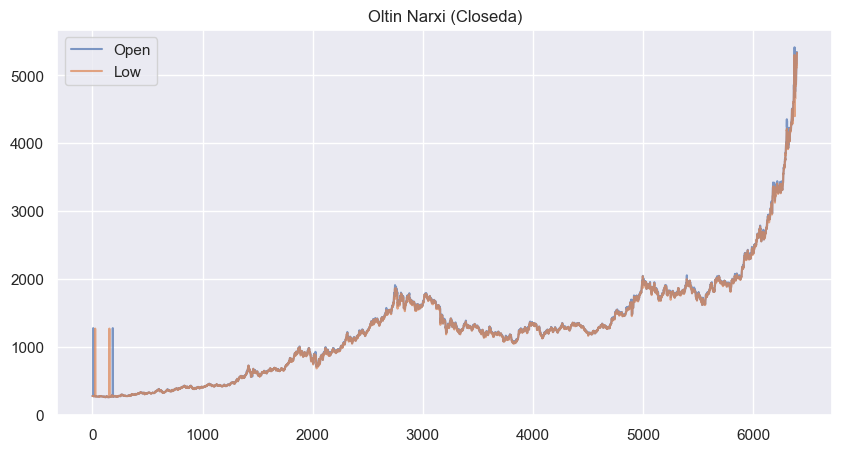

In [213]:
df[['Open', 'Low']].plot(figsize=(10,5), title='Oltin Narxi (Closeda)', alpha=0.7)
plt.show()

# Bu yerda biz oltin solishini boshidagi va oxiridagi qiymatlarini ko'rdik. deyarli tafovvut bilinar-bilinmas holatda

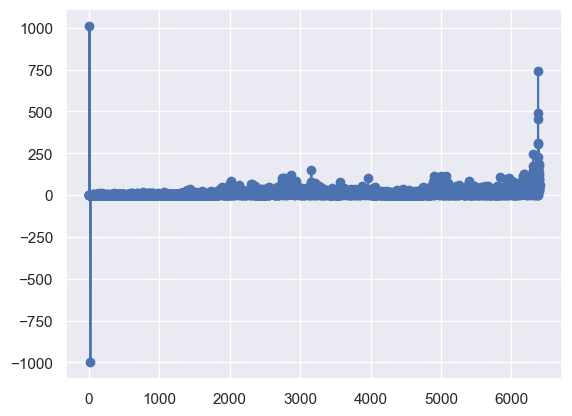

In [214]:
df['high_low'] = df['High'] - df['Low']
df['high_low'].plot(x='Kun', y='Qiymat', marker="o")
plt.show()

# Bunda esa biz eng yuqori va past qiymatlarini orasidagi tafovvut kunlar kesimida qanchalik o'zgarganin ko'rishimiz mumkin. 

In [215]:
import numpy as np 

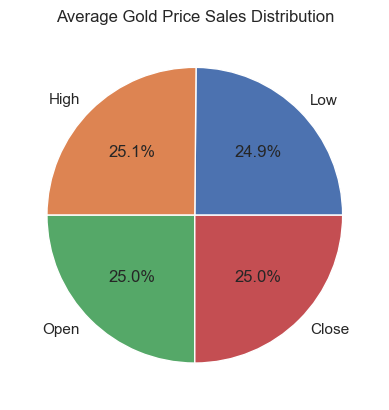

In [216]:
values = df[['Low', 'High', 'Open', 'Close']].mean()
plt.pie(values, labels=values.index, autopct='%1.1f%%')
plt.title('Average Gold Price Sales Distribution')
plt.show()


# Bu yerda esa biz ularni o'rta arifmetik qitmarlarin pie chartda foizlarda kesimlarini ko'rishimiz mumkin  

In [217]:
import seaborn as sns 
sns.set_theme()


<Axes: >

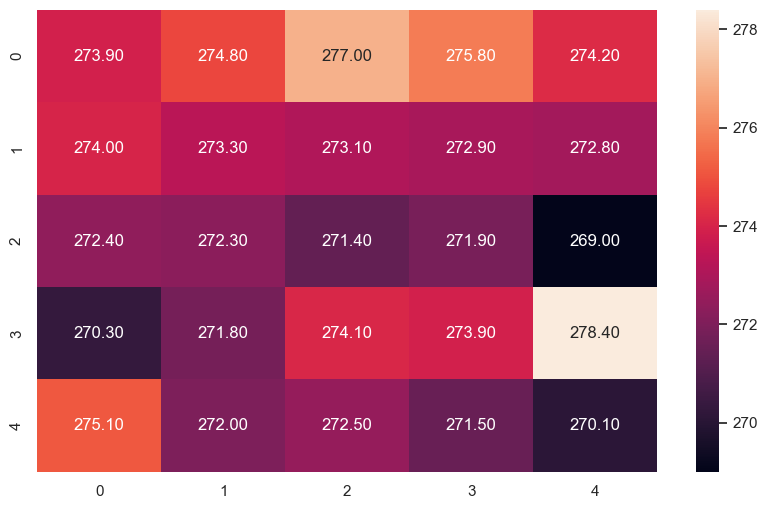

In [218]:
data = sales_gold['Low'].head(25).values
data2 = data.reshape(5, 5) 

f, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(data2, annot=True, fmt='.2f', ax=ax)


# bu yerda esa seaborn orqali heatmap qildim yani 270-278 gacha oraliqni faqat 30 ta yani cheklangan qiymatlarda ko'rdim.

In [219]:
import plotly.express as px
fig = px.scatter_matrix(df, dimensions=["Close","Open", "Low","High"], color="Close")
fig.show()

# Bu yerda esa men plotlydan foydalangan holda ancha interaktiv holatda har bir ustunndan 25 tadan qiymat olan holarda ularni qiymatlari orasidagi farqalrni ko'rdim. 

# Preprocessed bo'lgan datasetni papkaga joylash

In [220]:
#import os 
import os 

In [221]:
output_folder = 'data/preprocessed'
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, 'preprocessed_data.csv')
df.to_csv(output_path, index=False) # Tayyorlangan datasetni saqlash
print(f"Preprocessed dataset saved to : {output_path}")
 

Preprocessed dataset saved to : data/preprocessed/preprocessed_data.csv


# Joblib orqali esa data vialuationni data analysis folderga qo'shish

In [222]:
from joblib import dump, load

In [223]:
dump(df, 'data_viz.pkl') # men joblibni o'tkan edim ammo pklda qildim bu men uchun yangilik bo'ldi. 

['data_viz.pkl']

# Mening datasetimning unique valualari regressionligi sabab bo'  men regressionli algoritmlardan foydalanaman.

# Lasso, Ridge Regressionlar orqalia analyze qilish 

In [235]:
from sklearn.linear_model import Lasso, Ridge

In [236]:
lasso = Lasso(alpha=0.1)  # alphani baland olsak overfittingga moyil, past olsak underfittingga moyil bo'ladi.

In [237]:
x = df.drop('Close', axis=1)
y = df['Close']

In [238]:
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [239]:
lasso

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [240]:
lasso.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.837e+05, tolerance: 3.092e+05
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [241]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6399 non-null   float64
 1   High    6399 non-null   float64
 2   Low     6399 non-null   float64
 3   Close   6399 non-null   float64
 4   Volume  6399 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


In [243]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6399 non-null   float64
 1   High    6399 non-null   float64
 2   Low     6399 non-null   float64
 3   Close   6399 non-null   float64
 4   Volume  6399 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


In [244]:
y_pred = lasso.predict(x_test)


In [245]:
y_pred[0:10]

array([1211.6847855 , 2643.20281066, 1642.52890824, 1195.85377321,
        266.04621473, 2013.49893989,  437.81394156,  291.15722863,
       1207.2569286 ,  280.62864446])

# Evaluation 

In [247]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [248]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9981297844912287
mae: 7.674818394974953
mse: 1213.4938225804265


# Ridge Regressionda

In [249]:
ridge = Ridge(alpha=10)
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [250]:
ridge.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [251]:
y_rid_pred = ridge.predict(x_test)

In [252]:
y_rid_pred[1:10]

array([2646.43162412, 1642.10192265, 1197.59555365,  266.02435846,
       2015.72346548,  437.80124009,  291.18300233, 1208.70278323,
        280.47429078])

In [254]:
r2 = r2_score(y_test, y_rid_pred)
mae = mean_absolute_error(y_test, y_rid_pred)
mse = mean_squared_error(y_test, y_rid_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9983679759743165
mae: 6.956641408464558
mse: 1058.942706966872


# Cross validation: KFold, cross_val_score

In [255]:
from sklearn.model_selection import KFold, cross_val_score

In [259]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lasso, x, y, cv=kf, scoring='neg_mean_absolute_error')
print(-scores)

[7.67481839 6.14779561 6.57977777 6.65410535 6.25846817]


/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.837e+05, tolerance: 3.092e+05
  model = cd_fast.enet_coordinate_descent(
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.342e+06, tolerance: 3.210e+05
  model = cd_fast.enet_coordinate_descent(
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converg

In [260]:
# Haqiqatdan ham 5 ta qismga bo'lib, uni shaffle qilgan holatda ham deyarli bir hil bo'layapti yuqoridagi mae lar bialan


In [266]:
import numpy as np
print(np.mean(-scores)) # bu o'rta arifmetigi 
print(np.std(-scores))  # bu esa malumotlar meandan qancahlik yoyilganligini yoki tarqalganligini ko'rsatadi.

6.662993060393464
0.5403449044328198


In [267]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# DecisionTreeRegressor

In [268]:
dt = DecisionTreeRegressor()


In [269]:
dt.fit(x_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [270]:
y_dt_pred = dt.predict(x_test)

# DTR evaluation

In [271]:
r2 = r2_score(y_test, y_dt_pred)
mae = mean_absolute_error(y_test, y_dt_pred)
mse = mean_squared_error(y_test, y_dt_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9985809365272899
mae: 6.437356176133912
mse: 920.7627409285253


# RandomForestRegressor

In [273]:
rf = RandomForestRegressor()
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [274]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [275]:
y_rf_pred = rf.predict(x_test)

# RFR evaluation

In [276]:
r2 = r2_score(y_test, y_rf_pred)
mae = mean_absolute_error(y_test, y_rf_pred)
mse = mean_squared_error(y_test, y_rf_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9985875206646081
mae: 5.3640686116725265
mse: 916.4906076234244


# Support Vector Machine Regressor: SVR

In [277]:
svm = SVR()

In [278]:
svm.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [279]:
y_svm_pred = svm.predict(x_test)

# SVR evaluation

In [280]:
r2 = r2_score(y_test, y_svm_pred)
mae = mean_absolute_error(y_test, y_svm_pred)
mse = mean_squared_error(y_test, y_svm_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')
# bu yerda natija juda yomon chiqqanligining eng asosiy sababi shuki
# SVM da scaling qilish juda muhimligida edi. 

r2_score: 0.05524908663021022
mae: 563.3289999784669
mse: 613003.8981468088


# Endi esa Klib bilan ham tekshirib ko'ramiz
#               ---Uning qulayliklar---
# -Data haqida ma'lumot olish.
# -Malumotlarni tozalash usullaridan biri.
# -Duplicated bo'lganlarni ham tozalaydi va hajmini kamaytiradi.
# -Vizual chizmalar orqali analiz imkonini beradi.
# -Ustun nomlarini standard holatga keltiradi.

In [281]:
import pandas as pd
import klib 


In [296]:
df = pd.read_csv('data/raw/raw_data.csv')

In [297]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6397 non-null   float64
 1   High    6397 non-null   float64
 2   Low     6397 non-null   float64
 3   Close   6398 non-null   float64
 4   Volume  6396 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


GridSpec(6, 6)

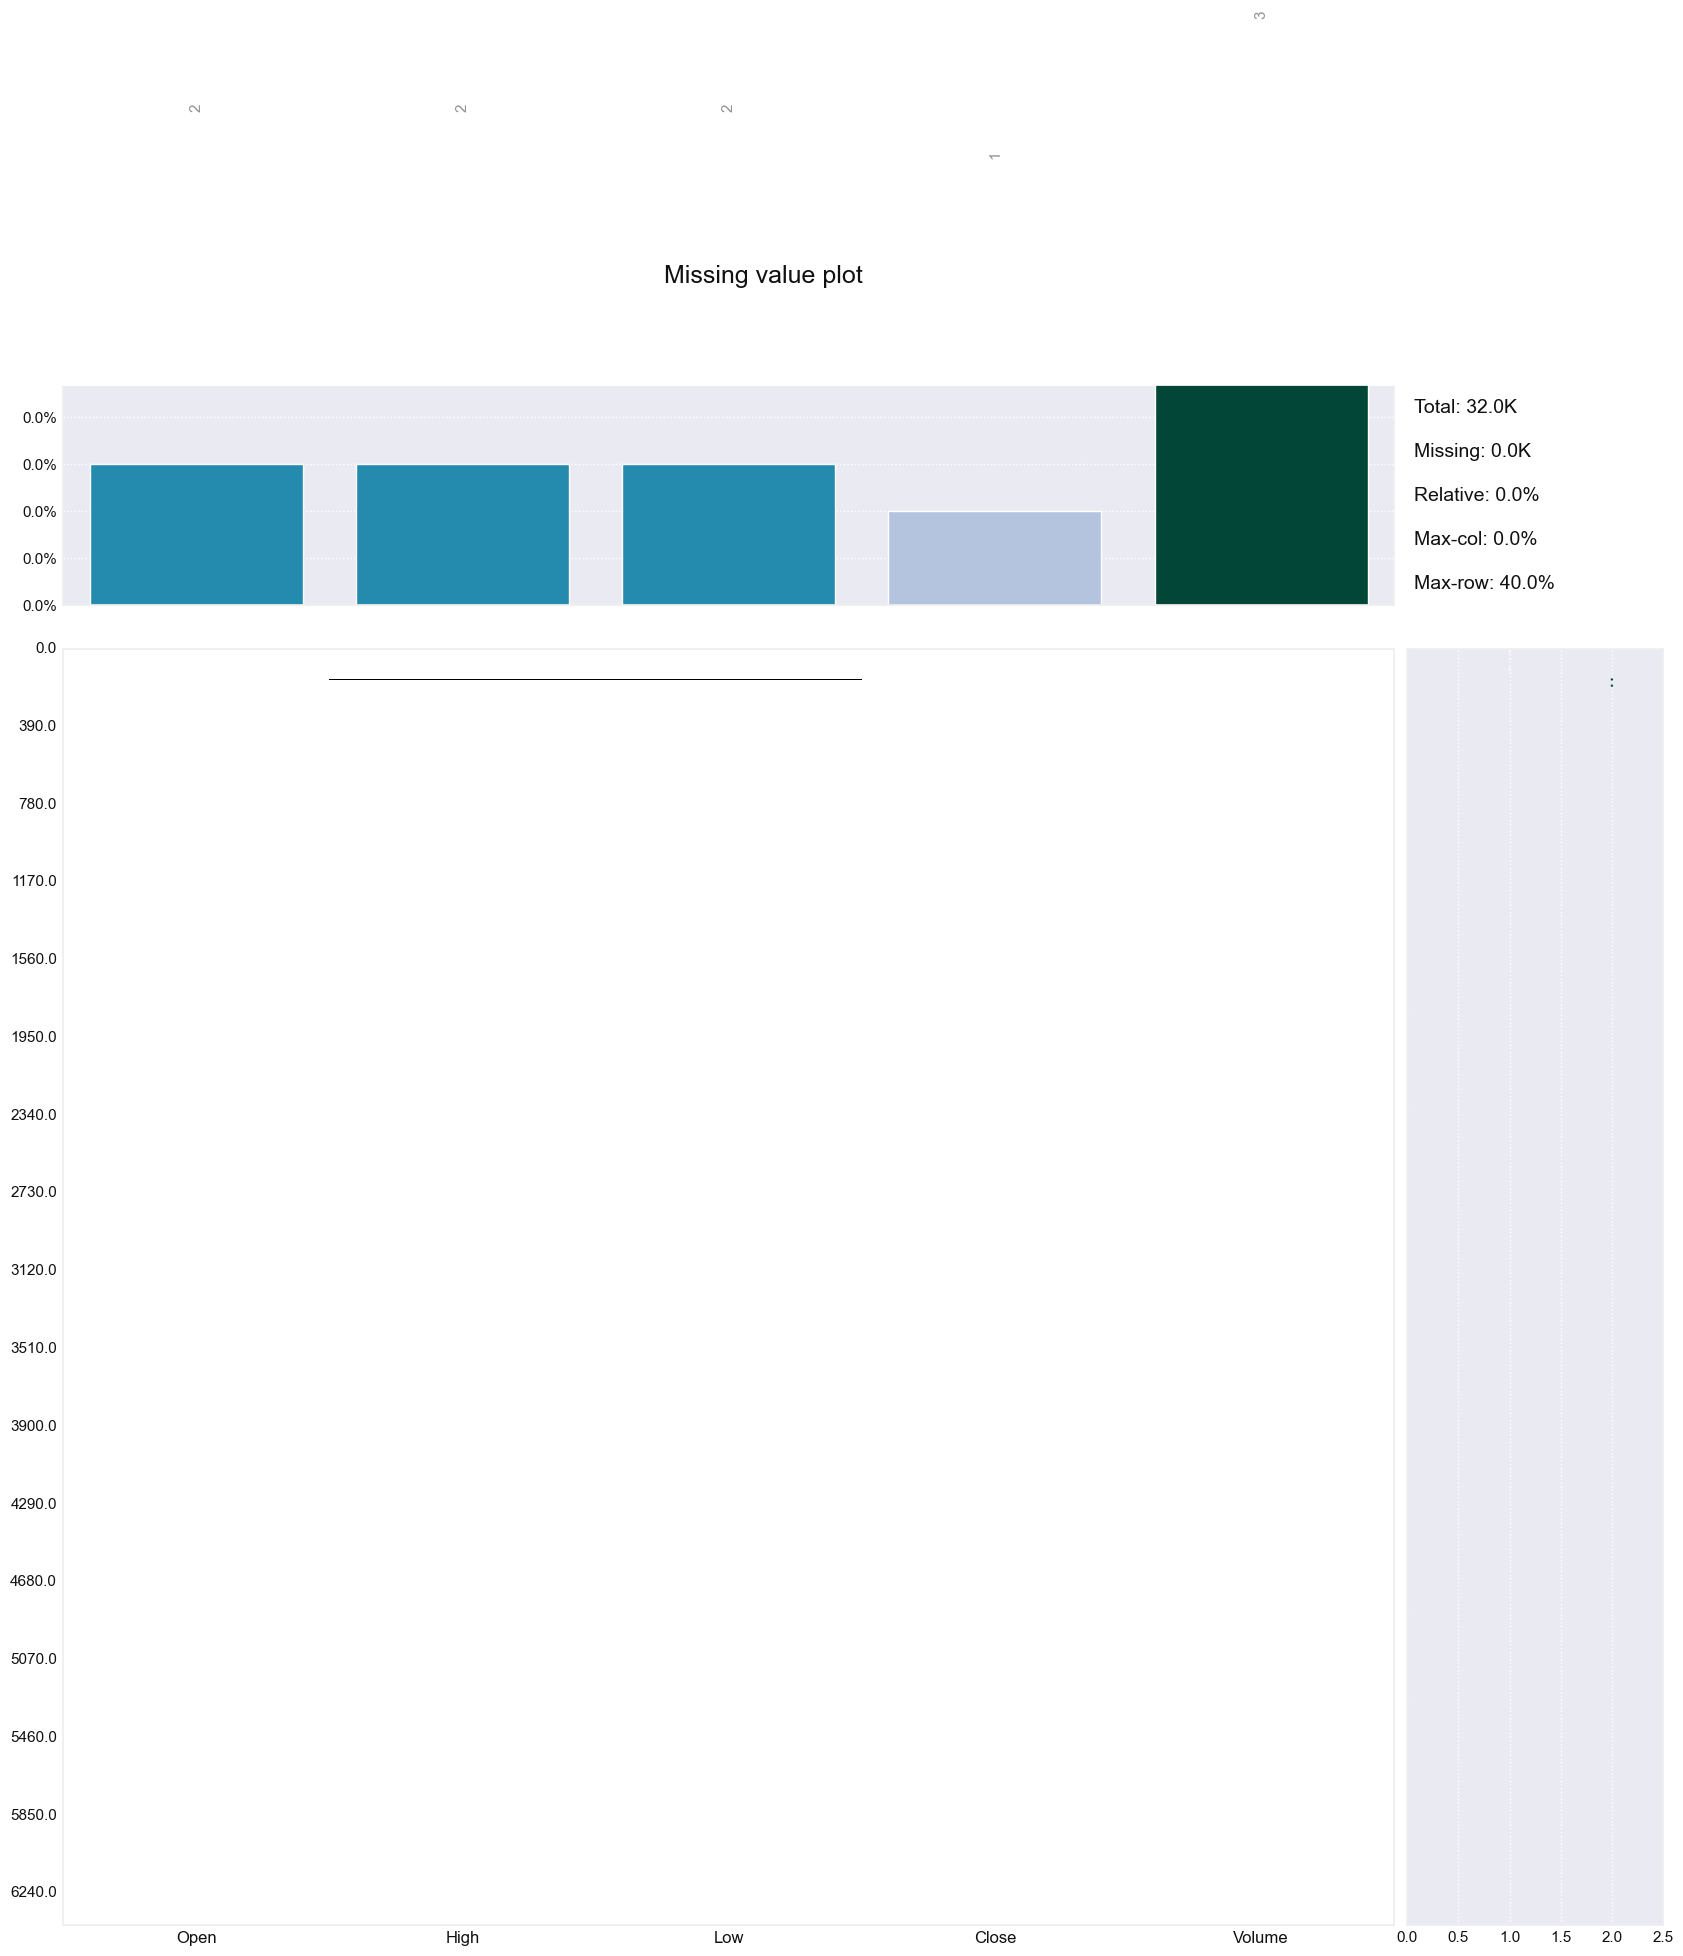

In [300]:
klib.missingval_plot(df)

In [301]:
klib.corr_interactive_plot(df_copy, annot=True, figsize=(10,5))

ValueError: underlying array is read-only

In [302]:
klib.data_cleaning(df, drop_duplicates=True)

Shape of cleaned data: (6358, 5) - Remaining NAs: 10


Dropped rows: 41
     of which 41 duplicates. (Rows (first 150 shown): [18, 34, 51, 59, 88, 92, 96, 99, 100, 132, 141, 165, 166, 167, 168, 169, 170, 171, 177, 215, 249, 254, 257, 301, 305, 306, 307, 333, 342, 379, 385, 416, 540, 1096, 1159, 1206, 1496, 1554, 1578, 1670, 1720])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.12 MB (-50.0%)



,open,high,low,close,volume
0,273.899994,273.899994,273.899994,273.899994,0.0
1,274.799988,278.299988,274.799988,278.299988,0.0
2,277.000000,277.000000,277.000000,277.000000,0.0
3,275.799988,275.799988,275.799988,275.799988,2.0
4,274.200012,274.200012,274.200012,274.200012,0.0
...,...,...,...,...,...
6353,5166.000000,5206.399902,5166.000000,5206.399902,1772.0
6354,5177.200195,5199.200195,5143.899902,5176.500000,1520.0
6355,5186.700195,5280.000000,5176.700195,5230.500000,354.0
6356,5346.600098,5405.000000,5266.299805,5294.399902,354.0


# Data Cleaner

In [303]:
from datacleaner import autoclean
df = autoclean(df)  # bu bilan birdaniga datani tozalaymiz va encoding (lable) qilamiz.


/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/datacleaner/datacleaner.py:77: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  input_dataframe[column].fillna(input_dataframe[column].median(), inplace=True)
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/s

In [304]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6397 non-null   float64
 1   High    6397 non-null   float64
 2   Low     6397 non-null   float64
 3   Close   6398 non-null   float64
 4   Volume  6396 non-null   float64
dtypes: float64(5)
memory usage: 250.1 KB


# Lasso, Ridge Regression

In [305]:
from sklearn.linear_model import Lasso, Ridge

In [306]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)


In [308]:
lasso.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.837e+05, tolerance: 3.092e+05
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [309]:
y_lasso_pred = lasso.predict(x_test)

# Klib: Lasso Regressor evaluation

In [310]:
r2 = r2_score(y_test, y_lasso_pred)
mae = mean_absolute_error(y_test, y_lasso_pred)
mse = mean_squared_error(y_test, y_lasso_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9981297844912287
mae: 7.674818394974953
mse: 1213.4938225804265


# Klib: DecisionTreeRegressor

In [311]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()

In [312]:
dt.fit(x_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [313]:
y_dt_pred = dt.predict(x_test)

# Klib: DecisionTreeRegressor evaluation

In [314]:
r2 = r2_score(y_test, y_dt_pred)
mae = mean_absolute_error(y_test, y_dt_pred)
mse = mean_squared_error(y_test, y_dt_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9984357432213844
mae: 6.742553626368289
mse: 1014.971766022137


# RandomForestRegressor

In [315]:
from sklearn.ensemble import RandomForestRegressor

In [316]:
rf = RandomForestRegressor()

In [317]:
rf.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [318]:
y_rf_pred = rf.predict(x_test)

# Klib: RandomForestRegressor evaluation

In [319]:
r2 = r2_score(y_test, y_dt_pred)
mae = mean_absolute_error(y_test, y_dt_pred)
mse = mean_squared_error(y_test, y_dt_pred)

print(f'r2_score: {r2}')
print(f'mae: {mae}')
print(f'mse: {mse}')

r2_score: 0.9984357432213844
mae: 6.742553626368289
mse: 1014.971766022137


# Support Vector Machine Regressor